# Numerical diagnostics

In [13]:
from functools import partial
import numpy as np
from lucifex.fdm import GridFunctionSeries, NPyConstantSeries
from lucifex.fem import refine_grid_function, grid_average
from lucifex.viz import (
    plot_colormap, plot_line, save_figure,
    plot_colormap_multifigure, plot_line_multifigure,
)
from lucifex.utils.array_utils import as_index
from lucifex.io import create_dir_path, find_dir_paths
from lucifex.utils.py_utils import FrozenDict
from lucifex.sim import GridSimulationFromNPZ
from crocodil.dns.system_a import (
    SYSTEM_A_REFERENCE, mass_dissolved_asymptote, mass_capillary_asymptote,
    mass_dissolved_initial, mass_capillary_initial,
)

PARAM_NAME = 'Ra'
PARAM_TEX = 'Ra'

PARAMS_NUMERICAL = FrozenDict(
    c_stabilization=None,
    c_limits=True,
)
DIR_ROOT = create_dir_path(
    PARAMS_NUMERICAL, 
    dir_root='./',
    dir_prefix='data', 
    dir_params=PARAMS_NUMERICAL.keys(), 
)
DIR_FIGS = f'{DIR_ROOT}/figures'
save_figure = partial(save_figure, dir_path=DIR_FIGS, prefix=PARAM_NAME)

N_STOP = 50_000
sim_dir_paths = find_dir_paths(
    DIR_ROOT, 
    include=f'n_stop={N_STOP}_*',
    contains=('CHECKPOINT.h5', 'c.npz'),
)
print('Before parameter filtering')
for i in sim_dir_paths: print(i)

simulations = GridSimulationFromNPZ.dict_from_dir_paths(
    PARAM_NAME, 
    sim_dir_paths,
    ('c', 's', 'cCorr'),
    ('mD', 'mC', 'uDiv'),
    SYSTEM_A_REFERENCE,
    lazy=False,
)

print('After parameter filtering')
for i in simulations.values(): print(i.dir_path)

epsilon, zeta0, sr, cr, aspect = SYSTEM_A_REFERENCE['epsilon', 'zeta0', 'sr', 'cr', 'aspect']
Ly = 1.0
Lx = aspect * Ly

Before parameter filtering
./data__c_stabilization=None|c_limits=True/n_stop=50000__Ra=500.0|Da=10.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__c4deca4f8fe27111/
./data__c_stabilization=None|c_limits=True/n_stop=50000__Ra=500.0|Da=100.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__cdefe0d77fe0ec33/
./data__c_stabilization=None|c_limits=True/n_stop=50000__Ra=500.0|Da=1000.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__e5615d686d9c78ab/
./data__c_stabilization=None|c_limits=True/n_stop=50000__Ra=1000.0|Da=10.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=200|Ny=200__6960ce4014553e45/
./data__c_stabilization=None|c_limits=True/n_stop=50000__Ra=1000.0|Da=100.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=200|Ny=200__34ee6f0aa42efdfd/
./data__c_stabilization=None|c_limits=True/n_stop=50000__Ra=1000.0|Da=1000.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=200|Ny=200__476f009e5105f01c/
./data__c_stabilization=None|c_lim

## Concentration limits

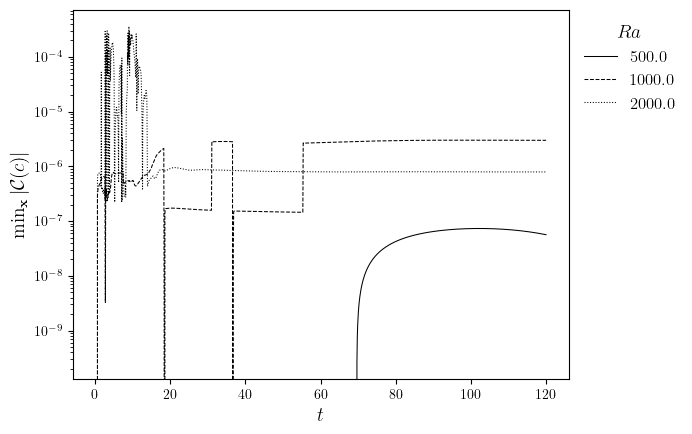

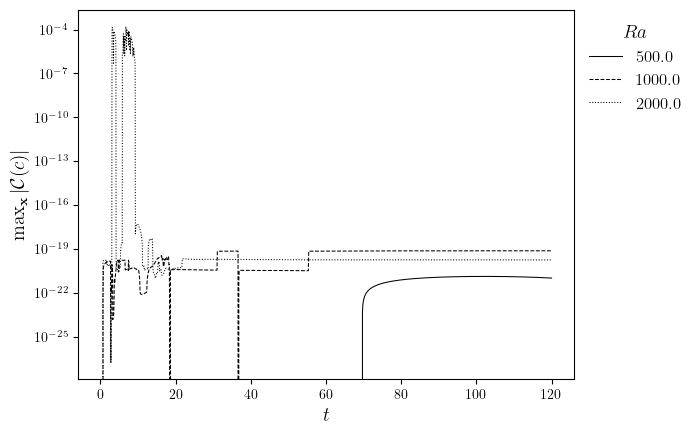

In [ ]:
legend_labels = []
cCorrMin_lines, cCorrMax_lines = [], []

for param_value, sim in simulations.items():
    legend_labels.append(param_value)
    cCorr = sim['cCorr']
    cCorrMin_lines.append(
        (cCorr.time_series, [np.abs(np.min(i.value)) for i in cCorr.series])
    )
    cCorrMax_lines.append(
        (cCorr.time_series, [np.abs(np.max(i.value)) for i in cCorr.series])
    )

line_kws = dict(
    cyc='black',
    x_label='$t$',
    legend_labels=legend_labels,
    legend_title=f'${PARAM_TEX}$',
)

fig, ax = plot_line(
    cCorrMin_lines, 
    y_label='$\min_{\mathbf{x}}|\mathcal{C}(c)|$',
    **line_kws,
)
ax.set_yscale('log')

fig, ax = plot_line(
    cCorrMax_lines, 
    y_label='$\max_{\mathbf{x}}|\mathcal{C}(c)|$',
    **line_kws,
)
ax.set_yscale('log')

## Velocity norms

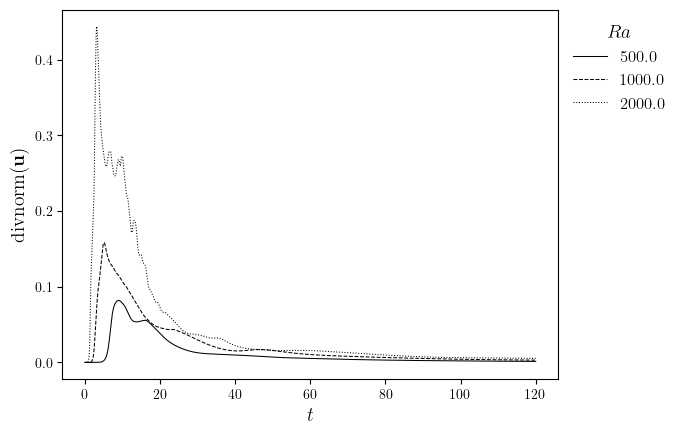

In [14]:
legend_labels, uDiv_lines = [], []

for param_value, sim in simulations.items():
    legend_labels.append(param_value)
    uDiv = sim['uDiv']
    uDiv_lines.append((uDiv.time_series, uDiv.value_series))

fig, ax = plot_line(
    uDiv_lines, 
    y_label='$\mathrm{divnorm}(\mathbf{u})$',
    x_label='$t$',
    cyc='black',
    legend_labels=legend_labels,
    legend_title=f'${PARAM_TEX}$',
)

## Mass conservation

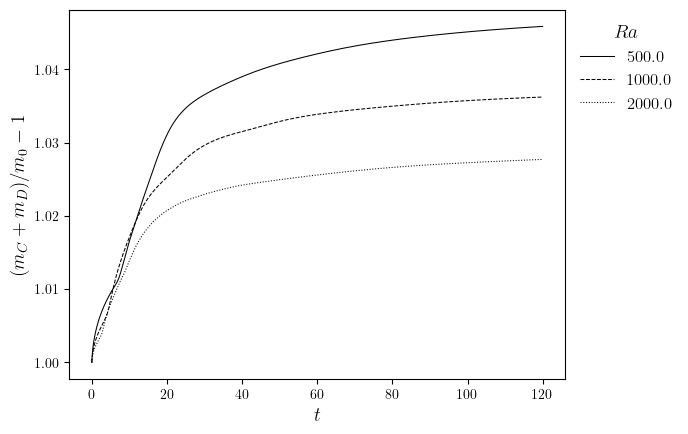

In [ ]:
legend_labels, mSum_lines = [], []

for param_value, sim in simulations.items():
    legend_labels.append(param_value)
    mC, mD = sim['mC', 'mD']
    mSum = np.array([i + j for i, j in zip(mC.value_series, mD.value_series)])
    mSum_lines.append(
        (mC.time_series, mSum / mSum[0])
    )

fig, ax = plot_line(
    mSum_lines, 
    y_label='$(m_C + m_D)/m_0 - 1$',
    x_label='$t$',
    cyc='black',
    legend_labels=legend_labels,
    legend_title=f'${PARAM_TEX}$',
)